In [17]:
# pip install torchvision

In [18]:
# pip install torchsummary

In [19]:
import os
import random
import numpy as np 
import time

import torch 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F 
import torch.utils.data as data 

import torchvision.transforms as transforms 
import torchvision.datasets as datasets
from torchsummary import summary

from sklearn.metrics import classification_report

import matplotlib as plt 
from PIL import Image

In [20]:
ROOT = './data' 

train_data = datasets.MNIST(
    root=ROOT, 
    train=True,
    download=True
)

test_data = datasets.MNIST(
    root = ROOT, 
    train = False, 
    download= True
)

In [21]:
# split data
VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = data.random_split(
    train_data,
    [n_train_examples, n_valid_examples]
)

# compute mean and std for [normalization]
mean = train_data.dataset.data.float().mean() / 255
std = train_data.dataset.data.float().std() / 255

train_transforms = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])
test_transforms = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

train_data.dataset.transform = train_transforms
valid_data.dataset.transform = test_transforms

In [22]:
# dataloader
BATCH_SIZE = 256

train_dataloader = data.DataLoader(
    train_data, 
    shuffle=True,
    batch_size=BATCH_SIZE
)

valid_dataloader = data.DataLoader(
    valid_data,
    batch_size=BATCH_SIZE
)

print(train_dataloader)
print(valid_dataloader)

In [23]:
class Modifier_model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=32, kernel_size=3, padding=1
        )
        self.avgpool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.avgpool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        
        self.fc_1 = nn.Linear(2304, 128)
        self.fc_2 = nn.Linear(128, 10)
        
    def forward(self, inputs):
        outputs = self.conv1(inputs)
        outputs = self.avgpool1(outputs)
        outputs = F.relu(outputs)
        
        outputs = self.conv2(outputs)
        outputs = self.avgpool2(outputs)
        outputs = F.relu(outputs)
        
        outputs = self.flatten(outputs)
        # print("Flatten:", outputs.shape)
        # print("FC expected:", self.fc_1.in_features)
        outputs = self.fc_1(outputs)
        outputs = self.fc_2(outputs)
        return outputs

In [24]:
def train(model, optimizer, criterion, train_dataloader, device, epoch=0, log_interval=50):
    model.train()
    total_acc = total_count = 0
    losses = []
    start_time = time.time()
    
    for idx, (inputs, labels) in enumerate(train_dataloader):
        inputs = inputs.to(device)
        # print(inputs.shape)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        predictions = model(inputs)
        
        loss = criterion(predictions, labels)
        losses.append(loss.item())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        total_acc += (predictions.argmax(1) == labels).sum().item()
        
        total_count += labels.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time () - start_time
            print(
            "| epoch {:3d} | {:5d}/{:5d} batches "
            "| accuracy {:8.3f}".format(epoch , idx , len(train_dataloader),total_acc / total_count)
            )
            total_acc , total_count = 0, 0
            start_time = time.time ()
    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss
            

In [25]:
def evaluate(model, criterion, train_dataloader, device):
    model.eval()
    total_acc = total_count = 0
    losses = []
    
    with torch.no_grad():
        for idx, (inputs, labels) in enumerate(train_dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            predictions = model(inputs)
            
            loss = criterion(predictions, labels)
            losses.append(loss.item())
            
            total_acc += (predictions.argmax(1) == labels).sum().item()
            total_count += labels.size(0)
        
    epoch_acc = total_acc / total_count
    epoch_loss = sum(losses) / len(losses)
    return epoch_acc, epoch_loss
                

In [26]:
num_classes = len(train_data.dataset.classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Modifier_model(num_classes)
model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

num_epochs = 10
save_model = './model'
os.makedirs(save_model, exist_ok=True)

train_accs, train_losses = [], []
eval_accs, eval_losses = [], []

best_loss_eval = float('inf')


for epoch in range(1, num_epochs+1):
    epoch_start_time = time.time()
    
    train_acc, train_loss = train(model, optimizer, criterion, train_dataloader, device, epoch)
    train_accs.append(train_acc)
    train_losses.append(train_loss)
    
    eval_acc, eval_loss = evaluate(model, criterion, valid_dataloader, device)
    eval_accs.append(eval_acc)
    eval_losses.append(eval_loss)
    
    if eval_loss < best_loss_eval:
        best_loss_eval = eval_loss
        torch.save(model.state_dict(), save_model + '/model.pt')
        
        
    print ( "-" * 59)
    print(
    "| End of epoch {:3d} | Time : {:5.2f}s | Train Accuracy {:8.3f} | Train Loss {:8.3f} "
    "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f}".format(
        epoch,
        time.time() - epoch_start_time,
        train_acc,
        train_loss,
        eval_acc,
        eval_loss
        )
    )
    print ( "-" * 59)
    # Load best model
    model.load_state_dict(torch.load(save_model + '/model.pt'))
    model.eval()

| epoch   1 |    50/  211 batches | accuracy    0.781
| epoch   1 |   100/  211 batches | accuracy    0.918
| epoch   1 |   150/  211 batches | accuracy    0.957
| epoch   1 |   200/  211 batches | accuracy    0.966
-----------------------------------------------------------
| End of epoch   1 | Time : 10.10s | Train Accuracy    0.972 | Train Loss    0.309 | Valid Accuracy    0.971 | Valid Loss    0.100
-----------------------------------------------------------
| epoch   2 |    50/  211 batches | accuracy    0.973
| epoch   2 |   100/  211 batches | accuracy    0.976
| epoch   2 |   150/  211 batches | accuracy    0.980
| epoch   2 |   200/  211 batches | accuracy    0.981
-----------------------------------------------------------
| End of epoch   2 | Time : 10.01s | Train Accuracy    0.989 | Train Loss    0.074 | Valid Accuracy    0.982 | Valid Loss    0.065
-----------------------------------------------------------
| epoch   3 |    50/  211 batches | accuracy    0.985
| epoch   3 

In [27]:
test_data.transform = test_transforms
test_dataloader = data.DataLoader(
    test_data, 
    batch_size=BATCH_SIZE
)

test_acc, test_loss = evaluate(model, criterion, test_dataloader, device)

test_acc, test_loss

(0.9889, 0.03421845936481986)

In [28]:
all_preds = []
all_labels = []

model = Modifier_model(num_classes)
model.load_state_dict(torch.load('./model/model.pt', map_location=device))
model.to(device)
model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:

        # print("Input:", images.shape)

        images = images.to(device)

        outputs = model(images)

        # print("Output:", outputs.shape)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())

        if torch.is_tensor(labels):
            all_labels.extend(labels.cpu().numpy())
        else:
            all_labels.append(labels)

In [29]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



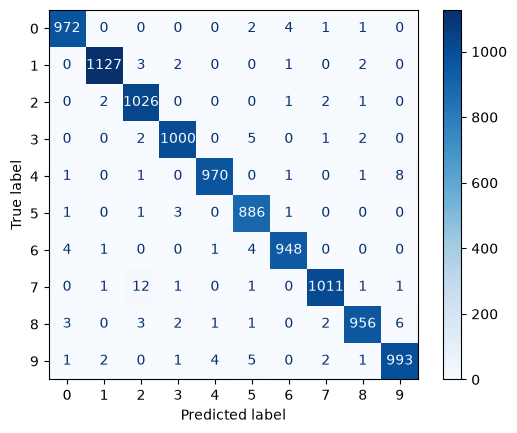

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds)).plot(cmap="Blues")
plt.savefig("confusion.png", dpi=200, bbox_inches="tight")